In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [15]:
df = pd.read_csv("Datasets/Churn_Modelling.csv")

In [5]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nHead:\n", df.head())

Shape: (10000, 14)
Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Head:
    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4      

In [6]:
# --- Clean & Prepare ---
# Drop irrelevant columns (IDs, names)
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

In [7]:
# Encode categorical features
le_geo = LabelEncoder()
df["Geography"] = le_geo.fit_transform(df["Geography"])

In [8]:
le_gender = LabelEncoder()
df["Gender"] = le_gender.fit_transform(df["Gender"])

In [9]:
# --- Features & Target ---
X = df.drop("Exited", axis=1)   # Exited = churn label
y = df["Exited"]

In [10]:
# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# --- Train Model (Random Forest) ---
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [12]:
# --- Evaluation ---
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8645
Confusion Matrix:
 [[1546   61]
 [ 210  183]]


In [13]:
# --- Feature Importance ---
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importance:\n", importances)


Feature Importance:
 Age                0.240453
EstimatedSalary    0.148004
CreditScore        0.142369
Balance            0.138670
NumOfProducts      0.132061
Tenure             0.080932
IsActiveMember     0.042807
Geography          0.037402
Gender             0.019032
HasCrCard          0.018269
dtype: float64


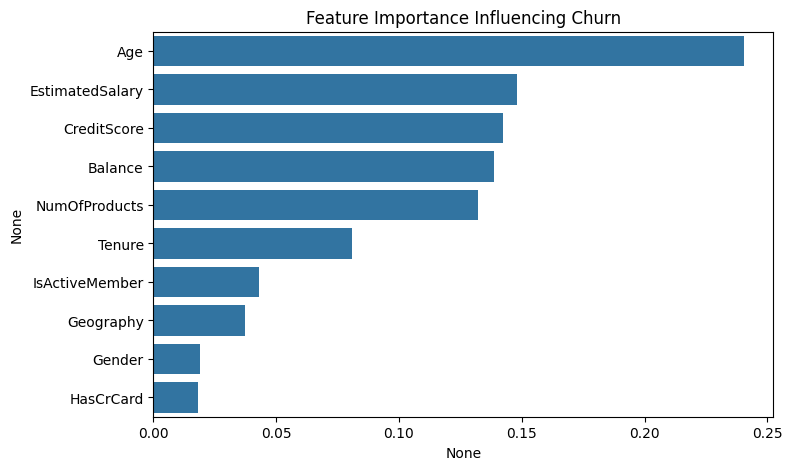

In [14]:
# --- Visualize Feature Importance ---
plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance Influencing Churn")
plt.show()